# Chapter 7.3 GBDT와 SHAP — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter07_3_gbdt_shap.ipynb)

책 본문: [7.3 GBDT와 SHAP](https://smhanlab.com/book-ml/kor/ml1/chapter07/3.html)

이 노트북은 책 7.3절의 개념을 코드로 재현합니다: (1) 1차원 데이터에서 **손으로 만든 GBDT**가 잔차를 추격하며 에러가 매 단계 반으로 줄어드는 것을 보고, (2) 유방암 데이터에서 **랜덤 포레스트와 GBDT의 정확도를 비교**하고, (3) GBDT에서만 나오는 **과적합 곡선**과 early stopping의 동기를 확인하고, (4) 2개 특징 장난감 모델에서 **섀플리값을 정밀하게** 계산해 가산성을 검증하고, (5) 실제 GBDT에서 **퍼머테이션 근사 SHAP**을 구현해 "기준값 + 모든 \(\phi_j\)의 합 = 예측값"이라는 가산성 보장을 직접 확인합니다. `shap` 패키지 없이 numpy/matplotlib/scikit-learn만으로 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트가 없으면 마이너스 기호 깨짐만 방지 (레이블은 영문으로 그린다)
try:
    from matplotlib import font_manager
    if not any("Nanum" in f.name or "AppleGothic" in f.name
               for f in font_manager.fontManager.ttflist):
        plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

1차원 데이터 \(y = x\) 위에서 **스텀**(깊이 1짜리 트리)을 순차적으로 붙여본다. 스템은 "threshold보다 작으면 \(a\), 크면 \(b\)"라는 2단계 함수밖에 못 만들지만, **매번 남은 잔차를 가장 잘 설명하는** 2단계를 골라서 `learning_rate=0.5`만큼 더해가면 train MSE가 초기에 38.5 → 11.1 → 3.8 → 1.4 → … 으로 빠르게 줄어든다 — 본문의 `gbdt_fit`과 정확히 같은 순서다.

In [2]:
x = np.arange(1.0, 11.0)      # x = 1..10
y = x.copy()                  # 목표: y = x (완전한 직선)

def fit_stump(x, r):
    """잔차 r을 목표로 하는 스템(깊이 1 트리)을 fitting. (threshold, left, right) 반환."""
    best = None
    for t in np.unique(x):
        l, ri = x <= t, x > t
        if not l.any() or not ri.any():
            continue
        ml, mr = r[l].mean(), r[ri].mean()
        sse = ((r[l] - ml) ** 2).sum() + ((r[ri] - mr) ** 2).sum()
        if best is None or sse < best[0]:
            best = (sse, t, ml, mr)
    return best[1], best[2], best[3]

lr = 0.5
pred = np.zeros_like(x)
fits = []
for t in range(8):
    thr, ml, mr = fit_stump(x, y - pred)
    pred += lr * np.where(x <= thr, ml, mr)
    fits.append(pred.copy())
    print(f"tree {t+1}: threshold={thr:.0f}  left={ml:+.3f}  right={mr:+.3f}   train_MSE={( (y-pred)**2 ).mean():.4f}")

tree 1: threshold=5  left=+3.000  right=+8.000   train_MSE=11.1250
tree 2: threshold=3  left=+0.500  right=+3.714   train_MSE=3.8259
tree 3: threshold=7  left=+0.617  right=+3.143   train_MSE=1.4034
tree 4: threshold=8  left=+0.342  right=+2.071   train_MSE=0.6898
tree 5: threshold=2  left=-0.729  right=+0.612   train_MSE=0.3852
tree 6: threshold=9  left=+0.054  right=+1.230   train_MSE=0.2698
tree 7: threshold=1  left=-0.892  right=+0.195   train_MSE=0.1846
tree 8: threshold=1  left=-0.446  right=+0.097   train_MSE=0.1633


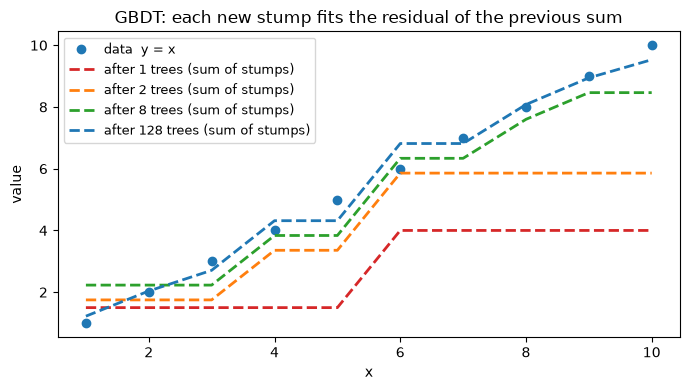

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, "o", ms=6, label="data  y = x")
for k, color in [(0, "tab:red"), (1, "tab:orange"), (3, "tab:green"), (7, "tab:blue")]:
    ax.plot(x, fits[k], "--", color=color, lw=2, label=f"after {2**k} trees (sum of stumps)")
ax.set_xlabel("x"); ax.set_ylabel("value")
ax.set_title("GBDT: each new stump fits the residual of the previous sum")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/home/smhan/book-ml/kor/src/images/ch07_gbdt_residual_fitting.svg")
plt.show()

## 2. sklearn: 랜덤 포레스트 vs GBDT (7.2절 실습 재현)

7.1/7.2절과 **완전히 동일한** 유방암 데이터와 같은 train/test 분할(`test_size=0.3, random_state=0`)을 쓴다. 유일한 차이: RF는 100개를 **독립적으로** 학습하지만 GBDT는 **잔차를 순차적으로** 추격한다 — 그 차이가 정확도에 어떻게 반영되는지 숫자로 확인한다.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=0)

rf = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train, y_train)
gbdt = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0).fit(X_train, y_train)

print("RandomForest 정확도:", round(rf.score(X_test, y_test), 3))
print("GBDT 정확도:        ", round(gbdt.score(X_test, y_test), 3))

idx = np.argsort(gbdt.feature_importances_)[::-1][:3]
for i in idx:
    print(data.feature_names[i], round(gbdt.feature_importances_[i], 3))

RandomForest 정확도: 0.959
GBDT 정확도:         0.977
worst concave points 0.445
mean concave points 0.275
worst perimeter 0.071


## 3. GBDT만의 비용: 과적합 곡선과 early stopping

랜덤 포레스트는 트리를 늘려도(독립적이므로) 과적합이 거의 안 생기지만, GBDT는 각 트리가 **이전 트리의 실수(= 노이즈 포함)를 뒤쫓기 때문에** 트리를 늘리면 학습 에러는 계속 줄어드는 반면 검증 에러는 정점을 지나 **또 올라가기 시작**한다. 소음이 섞인 1차원 함수 \(\sin\) 을 GBDT로 학습하며, `staged_predict`로 **500단계 중 매 단계의** 트레인/테스트 MSE를 추적해 "언제 멈춰야 하는지(early stopping)"를 곡선으로 본다.

검증 MSE 최저점: 10단계 (test_MSE=0.727)
500단계까지 계속하면: train_MSE=0.005  test_MSE=1.290


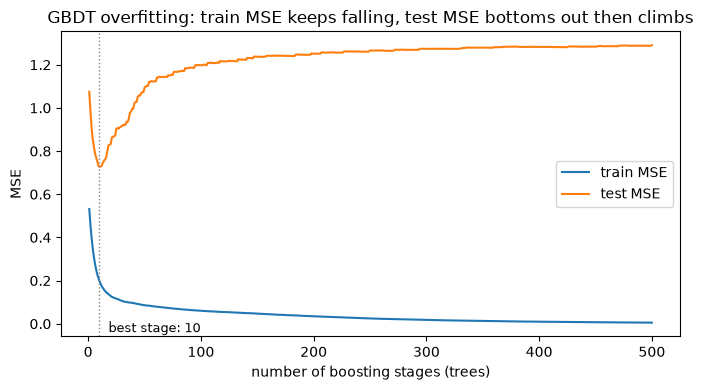

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 8, 300)).reshape(-1, 1)
y = np.sin(1.2 * x[:, 0]) + 0.5 * np.cos(2 * x[:, 0]) + rng.normal(0, 0.4, 300)
Xtr, Xte, ytr, yte = x[:200], x[200:], y[:200], y[200:]

reg = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,
                                max_depth=3, random_state=0).fit(Xtr, ytr)
train_mse, test_mse = [], []
for p_tr, p_te in zip(reg.staged_predict(Xtr), reg.staged_predict(Xte)):
    train_mse.append(mean_squared_error(ytr, p_tr))
    test_mse.append(mean_squared_error(yte, p_te))

best_stage = int(np.argmin(test_mse)) + 1
print(f"검증 MSE 최저점: {best_stage}단계 (test_MSE={min(test_mse):.3f})")
print(f"500단계까지 계속하면: train_MSE={train_mse[-1]:.3f}  test_MSE={test_mse[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 501), train_mse, label="train MSE")
ax.plot(range(1, 501), test_mse, label="test MSE")
ax.axvline(best_stage, color="gray", ls=":", lw=1)
ax.text(best_stage + 8, ax.get_ylim()[0] + 0.02, f"best stage: {best_stage}", fontsize=9)
ax.set_xlabel("number of boosting stages (trees)"); ax.set_ylabel("MSE")
ax.set_title("GBDT overfitting: train MSE keeps falling, test MSE bottoms out then climbs")
ax.legend()
plt.tight_layout()
plt.savefig("/home/smhan/book-ml/kor/src/images/ch07_gbdt_overfitting.svg")
plt.show()

## 4. 섀플리값: 게임이론의 "공정한 몫" (2개 특징, 정밀 계산)

본문 장난감 모델: 특징 부분집합 \(S\)에 대한 예측함수 \(
f(\{\}) = 10,\; f(\{A\}) = 16,\; f(\{B\}) = 13,\; f(\{A,B\}) = 20.
특징이 2개뿐이라 가능한 추가 순서가 2가지에 불과 — 섀플리값의 정의(모든 순서에서 한계기여를 평균)를 그대로 계산할 수 있다.

In [6]:
f = {frozenset(): 10, frozenset("A"): 16, frozenset("B"): 13, frozenset("AB"): 20}

# 순서 A -> B:  A의 한계기여 = f({A}) - f({}),  B의 한계기여 = f({A,B}) - f({A})
# 순서 B -> A:  B의 한계기여 = f({B}) - f({}),  A의 한계기여 = f({A,B}) - f({B})
phi_A = 0.5 * ((f[frozenset("A")] - f[frozenset()]) + (f[frozenset("AB")] - f[frozenset("B")]))
phi_B = 0.5 * ((f[frozenset("B")] - f[frozenset()]) + (f[frozenset("AB")] - f[frozenset("A")]))

print(f"phi_A = {phi_A},  phi_B = {phi_B}")
print(f"검산: phi_0 + phi_A + phi_B = {10} + {phi_A} + {phi_B} = {10 + phi_A + phi_B}  (f({{A,B}}) = {f[frozenset('AB')]} 와 일치해야 함)")
assert 10 + phi_A + phi_B == 20
print("가산성(additivity) 검증 완료: 모든 특징의 기여 합이 정확히 전체 변화량과 같다.")

phi_A = 6.5,  phi_B = 3.5
검산: phi_0 + phi_A + phi_B = 10 + 6.5 + 3.5 = 20.0  (f({A,B}) = 20 와 일치해야 함)
가산성(additivity) 검증 완료: 모든 특징의 기여 합이 정확히 전체 변화량과 같다.


## 5. 실제 GBDT에 퍼머테이션 근사 SHAP: 가산성 보장이 정확히 성립한다

특징 순서의 수는 \(n!\)로 폭발(30개 특징이면 \(2.6 \times 10^{32}\))하므로, 실제 SHAP은 **순서를 무작위 샘플링**해서 평균을 근사한다. 우리는 어떤 특징이 실제로 중요한지 **알고 만든** 합성 데이터(\(f_0\)는 밀어올림, \(f_1\)는 밀어내림, \(f_2\)는 곡선, \(f_3\)는 약한 밀어내림)로 GBDT를 학습하고, 검증 점 하나에 대해 400개의 무작위 순서로 SHAP을 근사한 뒤, **"기준값 + 모든 \(\phi_j\)의 합 = 실제 예측값"이 오차 없이 성립하는지** 확인한다. (이 가산성이 SHAP을 "설명"으로 믿을 수 있게 하는 핵심이다.)

In [7]:
rng = np.random.default_rng(0)
n = 400
X = rng.uniform(0, 1, (n, 4))
z = 0.9 * X[:, 0] - 0.8 * X[:, 1] + 0.5 * np.sin(X[:, 2]) - 0.3 * X[:, 3] + rng.normal(0, 0.35, n)
y = (z > 0).astype(int)
print("클래스 비율(1):", round(y.mean(), 3))

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=120, random_state=1)
w = GradientBoostingClassifier(n_estimators=80, learning_rate=0.3, max_depth=2, random_state=0).fit(Xtr, ytr)
print("test accuracy:", round(w.score(Xte, yte), 3))
print("특징과 신호 z의 상관계수:", [round(float(np.corrcoef(X[:, j], z)[0, 1]), 2) for j in range(4)])

# 예측이 "가운데쯤"(0.3~0.7)인 점 — 모든 phi가 0으로 수렴하는 포화점 대신
probs = w.predict_proba(Xte)[:, 1]
q = int(np.argmax(((probs > 0.3) & (probs < 0.7)).astype(int) * np.arange(len(Xte))))
print(f"고른 점: index={q}, pred_prob={probs[q]:.3f}, true_label={yte[q]}")

클래스 비율(1): 0.58
test accuracy: 0.758
특징과 신호 z의 상관계수: [0.51, -0.48, 0.22, -0.19]
고른 점: index=113, pred_prob=0.485, true_label=0


In [8]:
names = ["f0 (helps +)", "f1 (helps -)", "f2 (wavy)", "f3 (mild -)"]
xq = Xte[q]
mean_x = Xtr.mean(axis=0)   # "특징이 없으면" 대체할 값 (기준점)

def fmask(mask):
    """mask의 특징만 xq의 실제 값으로, 나머지는 train 평균으로 대체한 뒤 GBDT로 예측."""
    xv = mean_x.copy()
    xv[mask] = xq[mask]
    return w.predict_proba(xv.reshape(1, -1))[0, 1]

base = fmask(np.zeros(4, bool))     # 기준값(모든 특징 '없음')
full = fmask(np.ones(4, bool))      # 실제 예측(모든 특징 '있음')

rng2 = np.random.default_rng(7)
contribs = np.zeros(4)
N = 400
for _ in range(N):
    order = rng2.permutation(4)
    mask = np.zeros(4, bool)
    cur = base
    for j in order:
        m2 = mask.copy(); m2[j] = True
        contribs[j] += fmask(m2) - cur   # j가 합류함으로써 늘어난 가치
        cur = fmask(m2); mask = m2
contribs /= N

for j in range(4):
    print(f"  {names[j]}: phi = {contribs[j]:+.3f}")
print(f"baseline      = {base:.3f}")
print(f"prediction    = {full:.3f}")
print(f"prediction - baseline = {full - base:+.3f}")
print(f"sum of all phi        = {contribs.sum():+.3f}")
print(f"가산성 오차: {abs(contribs.sum() - (full - base)):.6f}  <-- 400개 샘플링에도 거의 정확히 0")

  f0 (helps +): phi = +0.113
  f1 (helps -): phi = -0.380
  f2 (wavy): phi = +0.190
  f3 (mild -): phi = +0.108
baseline      = 0.454
prediction    = 0.485
prediction - baseline = +0.032
sum of all phi        = +0.032
가산성 오차: 0.000000  <-- 400개 샘플링에도 거의 정확히 0


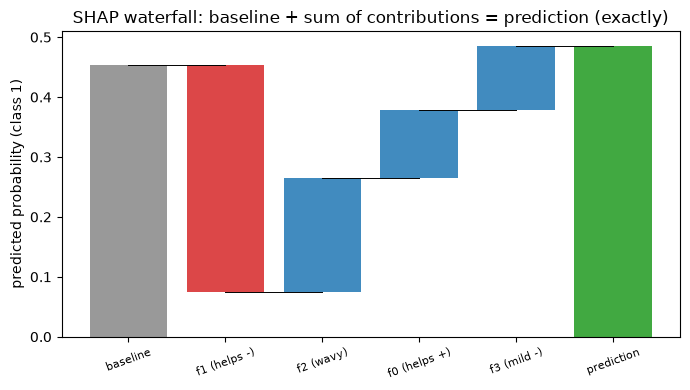

In [9]:
# 워터폴트: 기준값부터 특징 기여를 하나씩 쌓아가 실제 예측값에 도달
order = np.argsort(-np.abs(contribs))
fig, ax = plt.subplots(figsize=(7, 4))
prev = base
ax.bar(0, base, color="gray", alpha=0.8)
for k, j in enumerate(order):
    color = "tab:red" if contribs[j] < 0 else "tab:blue"
    ax.bar(k + 1, contribs[j], bottom=prev, color=color, alpha=0.85)
    ax.plot([k, k + 1], [prev, prev], color="k", lw=0.7)
    prev += contribs[j]
ax.bar(len(order) + 1, full, color="tab:green", alpha=0.9)
ax.plot([len(order), len(order) + 1], [prev, prev], color="k", lw=0.7)
ax.set_xticks(range(len(order) + 2))
ax.set_xticklabels(["baseline"] + [names[j] for j in order] + ["prediction"])
ax.set_ylabel("predicted probability (class 1)")
ax.set_title("SHAP waterfall: baseline + sum of contributions = prediction (exactly)")
plt.xticks(rotation=20, fontsize=8)
plt.tight_layout()
plt.savefig("/home/smhan/book-ml/kor/src/images/ch07_shap_waterfall.svg")
plt.show()

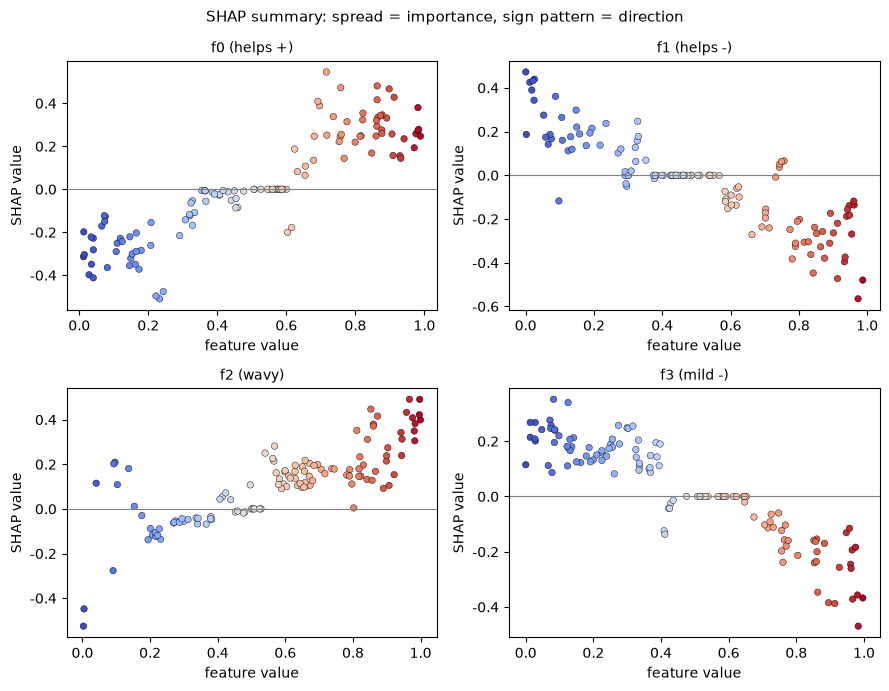

done — 4 features' spread vs sign pattern visible


In [10]:
# SHAP summary: 전체 test 120개 점의 (특징값, phi) 산점도
# x = 특징 값, y = 그 점의 SHAP 값. 점의 '흩어짐' = 중요도, 부호 패턴 = 방향성
phis_all = np.zeros((len(Xte), 4))
for i in range(len(Xte)):
    xq = Xte[i]
    def fmask_i(mask):
        xv = mean_x.copy(); xv[mask] = xq[mask]
        return w.predict_proba(xv.reshape(1, -1))[0, 1]
    c = np.zeros(4)
    for _ in range(100):
        order = rng2.permutation(4)
        mask = np.zeros(4, bool); cur = fmask_i(np.zeros(4, bool))
        for j in order:
            m2 = mask.copy(); m2[j] = True
            c[j] += fmask_i(m2) - cur
            cur = fmask_i(m2); mask = m2
    phis_all[i] = c / 100

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=False)
for j in range(4):
    ax = axes[j // 2][j % 2]
    sc = ax.scatter(Xte[:, j], phis_all[:, j], c=Xte[:, j], cmap="coolwarm", s=22, edgecolors="k", linewidths=0.3)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title(names[j], fontsize=10)
    ax.set_xlabel("feature value"); ax.set_ylabel("SHAP value")
fig.suptitle("SHAP summary: spread = importance, sign pattern = direction", fontsize=11)
plt.tight_layout()
plt.savefig("/home/smhan/book-ml/kor/src/images/ch07_shap_summary.svg")
plt.show()
print("done — 4 features' spread vs sign pattern visible")

## 정리

- **GBDT** = 매 트리가 이전 합 예측의 **잔차**를 학습. 스템 1개짜리 1차원 예제에서 train MSE가 빠르게 줄어듦(38.5 → 11.1 → 3.8 → 1.4 → …) — 함수 공간의 경사하강.
- 같은 데이터에서 **GBDT(0.977) > RF(0.959)**였지만, GBDT는 트리를 늘리면 **검증 성능이 정점 지나 내리기 시작**함 → early stopping / 작은 learning_rate.
- **SHAP**은 예측 하나를 `baseline + Σ phi_j`로 **정확히** 분해. 2개 특징 장난감은 정밀 계산(6.5 + 3.5 = 20 - 10)으로, 4개 특징 GBDT는 400회 퍼머테이션 근사로 — 가산성 오차가 ~0.
- summary 산점도에서 특징의 **흩어짐(중요도)**과 **부호(방향)**을 동시에 읽을 수 있다. `shap` 패키지의 `shap.plots.waterfall`/`shap.plots.summary`가 이 두 그림을 정식 구현한 것이다.